# CAS Hamiltonian Generation Tutorial

This notebook demonstrates how to use `symmer-pyscf` to generate **qubit Hamiltonians restricted to a Complete Active Space (CAS)**.

### Why CAS?

Full molecular Hamiltonians require `2 * n_orbitals` qubits, which quickly becomes impractical for near-term quantum hardware. A CAS Hamiltonian keeps only the chemically important ("active") orbitals, giving a smaller qubit Hamiltonian that still captures the essential correlation physics.

### Pipeline

```
Geometry + Basis
    -> RHF
    -> (optional) MP2 natural orbitals
    -> CASCI(ncas, nelecas)
    -> Extract CAS effective integrals
    -> InteractionOperator (openfermion)
    -> Jordan-Wigner
    -> PauliwordOp (symmer)
```

The returned `H_cas` is a `PauliwordOp` on `2 * ncas` qubits. Its eigenvalues need `e_core` added to give total energies.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from symmerpyscf import generate_cas_qubit_hamiltonian

## 1. Minimal example: H2 / STO-3G

H2 in the STO-3G basis has 2 spatial orbitals and 2 electrons.  
CAS(2,2) is the **full space** here, so the CASCI energy equals the exact FCI energy.

In [3]:
h2_geom = [("H", (0, 0, 0)), ("H", (0, 0, 0.735))]

h2 = generate_cas_qubit_hamiltonian(
    geometry=h2_geom,
    basis="sto-3g",
    ncas=2,
    nelecas=2,
)

print(f"Number of qubits: {h2['n_qubits']}")
print(f"E(HF):            {h2['e_hf']:.8f} Ha")
print(f"E(CASCI):         {h2['e_casci']:.8f} Ha")
print(f"E(FCI):           {h2['e_fci']:.8f} Ha")
print(f"Active electrons:  {h2['nelecas']}")

Number of qubits: 4
E(HF):            -1.11699900 Ha
E(CASCI):         -1.13730604 Ha
E(FCI):           -1.13730604 Ha
Active electrons:  (1, 1)


### Return value contents

The function returns a dictionary with everything you need for downstream quantum algorithms.

In [4]:
for key, val in h2.items():
    if isinstance(val, (int, float, tuple)):
        print(f"  {key:20s}  {val}")
    else:
        print(f"  {key:20s}  {type(val).__name__}")

  H_cas                 PauliwordOp
  H_fermion             FermionOperator
  e_core                0.7199689944489797
  cas_ground_state      QuantumState
  e_casci               -1.1373060357534004
  e_fci                 -1.1373060357534
  e_hf                  -1.1169989967540044
  n_qubits              4
  ncas                  2
  nelecas               (1, 1)


### Self-consistency check

The key invariant: `min(eigenvalue(H_cas)) + e_core == e_casci`

This verifies that the integral extraction, convention conversion, and qubit mapping are all correct.

In [5]:
H_mat = h2['H_cas'].to_sparse_matrix.toarray()
eigenvalues = np.linalg.eigvalsh(H_mat)

e_total = eigenvalues[0] + h2['e_core']

print(f"min(eig(H_cas)):       {eigenvalues[0]:.10f}")
print(f"e_core:                {h2['e_core']:.10f}")
print(f"Sum:                   {e_total:.10f}")
print(f"e_casci (from PySCF):  {h2['e_casci']:.10f}")
print(f"Difference:            {abs(e_total - h2['e_casci']):.2e}")

min(eig(H_cas)):       -1.8572750302
e_core:                0.7199689944
Sum:                   -1.1373060358
e_casci (from PySCF):  -1.1373060358
Difference:            0.00e+00


### Inspect the Hamiltonian

The `H_cas` object is a `PauliwordOp` — a sum of Pauli strings with coefficients.

In [6]:
print(f"Number of Pauli terms: {h2['H_cas'].n_terms}")
print(f"Number of qubits:      {h2['H_cas'].n_qubits}")
print()
print("Pauli decomposition:")
print(h2['H_cas'])

Number of Pauli terms: 15
Number of qubits:      4

Pauli decomposition:
-0.811+0.000j IIII +
 0.172+0.000j ZIII +
 0.172+0.000j IZII +
-0.226+0.000j IIZI +
-0.226+0.000j IIIZ +
 0.169+0.000j ZZII +
 0.045+0.000j YXXY +
-0.045+0.000j YYXX +
-0.045+0.000j XXYY +
 0.045+0.000j XYYX +
 0.121+0.000j ZIZI +
 0.166+0.000j ZIIZ +
 0.166+0.000j IZZI +
 0.121+0.000j IZIZ +
 0.175+0.000j IIZZ


### Inspect the ground state

In [7]:
print("CASCI ground state (top components):")
print(h2['cas_ground_state'])

# Verify: expectation value matches eigenvalue
e_expval = h2['H_cas'].expval(h2['cas_ground_state'])
print(f"\n<psi|H_cas|psi> = {e_expval.real:.10f}")
print(f"min(eig)        = {eigenvalues[0]:.10f}")

CASCI ground state (top components):
-0.112+0.000j |0011> +
 0.994+0.000j |1100>

<psi|H_cas|psi> = -1.8572750302
min(eig)        = -1.8572750302


---

## 2. Larger molecule: N2 / STO-3G

N2 in STO-3G has **10 spatial orbitals** and **14 electrons** (20 qubits full-space).  
We can choose different active spaces to trade accuracy for qubit count:

| Active Space | Qubits | Description |
|:---:|:---:|:---|
| CAS(4, 2) | 8 | Minimal: 4 orbitals, 2 electrons |
| CAS(6, 6) | 12 | Standard: 6 orbitals, 6 electrons |
| CAS(10, 14) | 20 | Full space: recovers FCI exactly |

In [8]:
n2_geom = [("N", (0, 0, 0)), ("N", (0, 0, 1.1))]
n2_basis = "sto-3g"

active_spaces = [(4, 2), (6, 6), (10, 14)]
n2_results = {}

for ncas, nelecas in active_spaces:
    r = generate_cas_qubit_hamiltonian(n2_geom, n2_basis, ncas=ncas, nelecas=nelecas)
    n2_results[(ncas, nelecas)] = r
    print(f"CAS({ncas:2d},{nelecas:2d})  done  --  {r['n_qubits']:2d} qubits,  "
          f"E(CASCI) = {r['e_casci']:.8f} Ha")

CAS( 4, 2)  done  --   8 qubits,  E(CASCI) = -107.53369832 Ha
CAS( 6, 6)  done  --  12 qubits,  E(CASCI) = -107.63723931 Ha
CAS(10,14)  done  --  20 qubits,  E(CASCI) = -107.65412245 Ha


### Energy comparison table

In [9]:
# All results share the same e_hf and e_fci (same molecule)
ref = n2_results[(4, 2)]
print(f"E(HF)  = {ref['e_hf']:.8f} Ha")
print(f"E(FCI) = {ref['e_fci']:.8f} Ha")
print()
print(f"{'Active Space':14s} {'Qubits':>6s} {'E(CASCI)':>16s} {'Error vs FCI':>14s}")
print("-" * 54)

for (ncas, nelecas), r in n2_results.items():
    err = r['e_casci'] - r['e_fci']
    label = f"CAS({ncas},{nelecas})"
    print(f"{label:14s} {r['n_qubits']:6d} {r['e_casci']:16.8f} {err:14.2e}")

E(HF)  = -107.49650051 Ha
E(FCI) = -107.65412245 Ha

Active Space   Qubits         E(CASCI)   Error vs FCI
------------------------------------------------------
CAS(4,2)            8    -107.53369832       1.20e-01
CAS(6,6)           12    -107.63723931       1.69e-02
CAS(10,14)         20    -107.65412245       3.17e-10


### Self-consistency for all active spaces

Verify `min(eig(H_cas)) + e_core == e_casci` for each.

In [10]:
from scipy.sparse.linalg import eigsh

for (ncas, nelecas), r in n2_results.items():
    mat = r['H_cas'].to_sparse_matrix
    if mat.shape[0] <= 64:
        e_min = np.linalg.eigvalsh(mat.toarray())[0]
    else:
        e_min = eigsh(mat, k=1, which='SA', return_eigenvectors=False)[0]

    diff = abs(e_min + r['e_core'] - r['e_casci'])
    status = 'PASS' if diff < 1e-8 else 'FAIL'
    print(f"CAS({ncas:2d},{nelecas:2d})  min(eig)+e_core = {e_min + r['e_core']:.8f}  "
          f"e_casci = {r['e_casci']:.8f}  diff = {diff:.2e}  [{status}]")

CAS( 4, 2)  min(eig)+e_core = -107.53369832  e_casci = -107.53369832  diff = 4.26e-14  [PASS]
CAS( 6, 6)  min(eig)+e_core = -107.63723931  e_casci = -107.63723931  diff = 1.28e-13  [PASS]
CAS(10,14)  min(eig)+e_core = -107.65412245  e_casci = -107.65412245  diff = 3.22e-10  [PASS]


---

## 3. Effect of MP2 natural orbitals

By default, `use_mp2_natorbs=True` rotates the orbital basis to MP2 natural orbitals before selecting the active space. This generally gives better CASCI energies for the same `(ncas, nelecas)`.

Let's compare for CAS(6,6) on N2.

In [11]:
r_mp2 = generate_cas_qubit_hamiltonian(n2_geom, n2_basis, ncas=6, nelecas=6, use_mp2_natorbs=True)
r_can = generate_cas_qubit_hamiltonian(n2_geom, n2_basis, ncas=6, nelecas=6, use_mp2_natorbs=False)

print(f"CAS(6,6) with MP2 natural orbitals: E = {r_mp2['e_casci']:.8f} Ha")
print(f"CAS(6,6) with canonical orbitals:   E = {r_can['e_casci']:.8f} Ha")
print(f"FCI reference:                      E = {r_mp2['e_fci']:.8f} Ha")
print(f"\nMP2 NOs improve energy by {r_can['e_casci'] - r_mp2['e_casci']:.6f} Ha")

CAS(6,6) with MP2 natural orbitals: E = -107.63723931 Ha
CAS(6,6) with canonical orbitals:   E = -107.62310177 Ha
FCI reference:                      E = -107.65412245 Ha

MP2 NOs improve energy by 0.014138 Ha


---

## 4. Bond dissociation curve

A common use case: compute energies at several bond lengths to map the potential energy surface. Here we compare HF, CAS(6,6), and FCI for N2.

In [12]:
bond_lengths = [0.9, 1.0, 1.1, 1.2, 1.4]
e_hf_list, e_cas_list, e_fci_list = [], [], []

for R in bond_lengths:
    geom = [("N", (0, 0, 0)), ("N", (0, 0, R))]
    r = generate_cas_qubit_hamiltonian(geom, "sto-3g", ncas=6, nelecas=6)
    e_hf_list.append(r['e_hf'])
    e_cas_list.append(r['e_casci'])
    e_fci_list.append(r['e_fci'])
    print(f"R = {R:.1f} A  |  E(HF) = {r['e_hf']:.6f}  "
          f"E(CAS) = {r['e_casci']:.6f}  E(FCI) = {r['e_fci']:.6f}")

R = 0.9 A  |  E(HF) = -107.187190  E(CAS) = -107.276570  E(FCI) = -107.293076
R = 1.0 A  |  E(HF) = -107.419532  E(CAS) = -107.532583  E(FCI) = -107.549301
R = 1.1 A  |  E(HF) = -107.496501  E(CAS) = -107.637239  E(FCI) = -107.654122
R = 1.2 A  |  E(HF) = -107.487784  E(CAS) = -107.660451  E(FCI) = -107.677340
R = 1.4 A  |  E(HF) = -107.357815  E(CAS) = -107.607230  E(FCI) = -107.623174


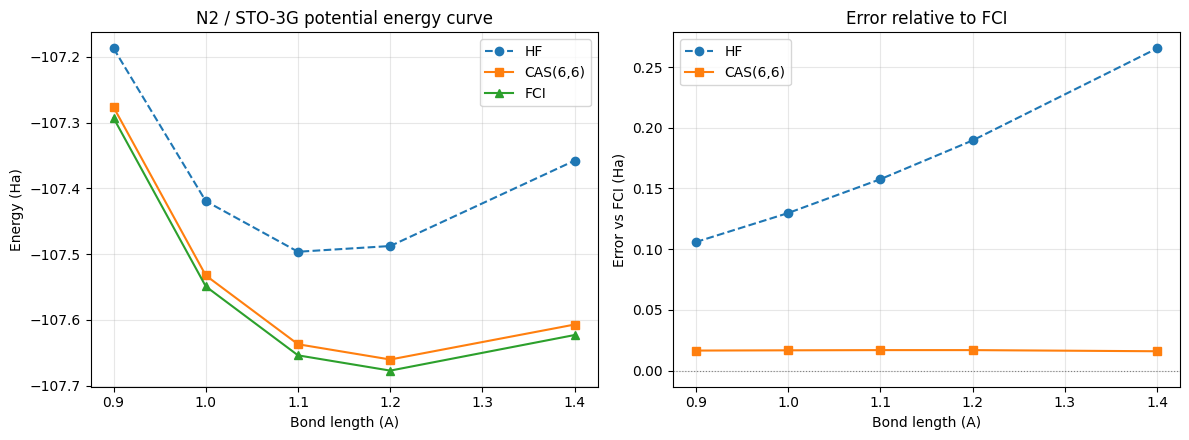

Plot saved to n2_cas_pes.png


In [13]:
try:
    import matplotlib.pyplot as plt

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    # Left panel: absolute energies
    ax1.plot(bond_lengths, e_hf_list, 'o--', label='HF')
    ax1.plot(bond_lengths, e_cas_list, 's-', label='CAS(6,6)')
    ax1.plot(bond_lengths, e_fci_list, '^-', label='FCI')
    ax1.set_xlabel('Bond length (A)')
    ax1.set_ylabel('Energy (Ha)')
    ax1.set_title('N2 / STO-3G potential energy curve')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Right panel: errors vs FCI
    err_hf = [h - f for h, f in zip(e_hf_list, e_fci_list)]
    err_cas = [c - f for c, f in zip(e_cas_list, e_fci_list)]
    ax2.plot(bond_lengths, err_hf, 'o--', label='HF')
    ax2.plot(bond_lengths, err_cas, 's-', label='CAS(6,6)')
    ax2.axhline(0, color='gray', ls=':', lw=0.8)
    ax2.set_xlabel('Bond length (A)')
    ax2.set_ylabel('Error vs FCI (Ha)')
    ax2.set_title('Error relative to FCI')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('n2_cas_pes.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved to n2_cas_pes.png")
except ImportError:
    print("matplotlib not installed -- skipping plot")
    print("Install with: pip install matplotlib")

---

## 5. Using the Hamiltonian for quantum algorithms

The returned `H_cas` is a `PauliwordOp` ready for use with symmer's quantum algorithm tools, or for export to other frameworks.

Here we show how to:
- Get the sparse matrix representation
- Compute expectation values
- Export the Pauli decomposition

In [14]:
# Use the CAS(6,6) N2 result
r66 = n2_results[(6, 6)]
H = r66['H_cas']
psi = r66['cas_ground_state']

# Sparse matrix (useful for classical exact diag or subspace methods like QSCI)
H_sparse = H.to_sparse_matrix
print(f"Hamiltonian matrix shape: {H_sparse.shape}")
print(f"Number of nonzero elements: {H_sparse.nnz}")
print(f"Sparsity: {H_sparse.nnz / np.prod(H_sparse.shape) * 100:.2f}%")

# Expectation value
e_expval = H.expval(psi)
print(f"\n<psi|H_cas|psi> = {e_expval.real:.8f}")
print(f"e_core          = {r66['e_core']:.8f}")
print(f"Total energy    = {e_expval.real + r66['e_core']:.8f} Ha")
print(f"e_casci (ref)   = {r66['e_casci']:.8f} Ha")

Hamiltonian matrix shape: (4096, 4096)
Number of nonzero elements: 278528
Sparsity: 1.66%

<psi|H_cas|psi> = -12.50004637
e_core          = -95.13719295
Total energy    = -107.63723931 Ha
e_casci (ref)   = -107.63723931 Ha


In [15]:
# Export Pauli decomposition as a dictionary
pauli_dict = H.to_dictionary
print(f"Number of Pauli terms: {len(pauli_dict)}")
print(f"\nFirst 5 terms:")
for i, (pauli, coeff) in enumerate(pauli_dict.items()):
    if i >= 5:
        break
    print(f"  {pauli}  {coeff.real:+.8f}")

Number of Pauli terms: 383

First 5 terms:
  IIIIIIIIIIII  -9.42969831
  ZIIIIIIIIIII  +0.24203501
  IZIIIIIIIIII  +0.24203501
  IIZIIIIIIIII  +0.16654387
  IIIZIIIIIIII  +0.16654387


---

## Summary

| Function | What it does | Qubits |
|:---|:---|:---|
| `generate_symmer_data()` | Full-space Hamiltonian + states | `2 * n_orbitals` |
| `generate_cas_qubit_hamiltonian()` | CAS-restricted Hamiltonian | `2 * ncas` |

**Key points:**
- `H_cas` does **not** include `e_core`. Add it to eigenvalues for total energies.
- `use_mp2_natorbs=True` (default) generally improves CAS energies.
- CAS(full space) recovers FCI exactly -- a useful sanity check.
- The `H_cas` PauliwordOp is directly usable in QSCI, VQE, or other quantum algorithms.